# 04 â€” Train M2: Speed Optimizer (Keras ANN Classifier)

**Goal:** Train a Keras Sequential ANN to predict optimal conveyor speed (5-class).

**Output:** `models/m2_speed_optimizer.keras`

## Step 1 â€” Setup & Imports

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, json, joblib, os
from pathlib import Path
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)
sns.set_style("whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "ml_model" else Path.cwd()
MODEL_DIR = ROOT / "ml_model" / "models"
PLOT_DIR = ROOT / "ml_model" / "plots"
MODEL_DIR.mkdir(exist_ok=True); PLOT_DIR.mkdir(exist_ok=True)
print(f"Model dir: {MODEL_DIR}")




Model dir: E:\Projects\iot-aiml-project\ml_model\models


## Step 2 â€” Load & Prepare Data

In [2]:
df = pd.read_csv(ROOT / "ml_model" / "data" / "syn_oee_10k.csv")
df = df.sort_values("Production_End_Time").reset_index(drop=True)
print(f"Loaded {len(df)} rows")

BASE = ["Availability","Performance","Quality","Current_OEE",
        "Current_Speed_pct","DownTime_sec","OEE_Delta",
        "Part_SLNo","_pos_ratio"]
LAGS = ["OEE_lag1","OEE_roll5_mean","OEE_trend3"]
state_dummies = pd.get_dummies(df['_state'], prefix='state')
df = pd.concat([df, state_dummies], axis=1)
FEATURES = BASE + LAGS + list(state_dummies.columns)
TARGET = "Recommended_Speed"

speed_map = {20:0, 40:1, 60:2, 80:3, 100:4}
inv_speed_map = {v:k for k,v in speed_map.items()}

print(f"Target distribution:\n{df[TARGET].value_counts().sort_index()}")


Loaded 10000 rows
Target distribution:
Recommended_Speed
40      817
60      734
80      254
100    8195
Name: count, dtype: int64


## Step 3 â€” Split & Scale

In [3]:
split = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split].copy(), df.iloc[split:].copy()

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].map(speed_map).values
X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].map(speed_map).values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
joblib.dump(scaler, MODEL_DIR / "scaler_m2.pkl")

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class distribution:")
for c in range(5):
    print(f"  {inv_speed_map[c]}%: {(y_train==c).sum()}")


Train: (8000, 17), Test: (2000, 17)
Train class distribution:
  20%: 0
  40%: 700
  60%: 615
  80%: 201
  100%: 6484


## Step 4 â€” Build Keras ANN Classifier

In [4]:
def build_classifier(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'), Dropout(0.2),
        Dense(32, activation='relu'), Dropout(0.1),
        Dense(5, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

m = build_classifier(len(FEATURES))
m.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,397 (13.27 KB)

 Trainable params: 3,397 (13.27 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5 â€” Train

In [5]:
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
m = build_classifier(len(FEATURES))
h = m.fit(
    X_train, y_train, validation_split=0.2,
    batch_size=32, epochs=200, callbacks=[es], verbose=1
)



Epoch 1/200


  1/200 ━━━━━━━━━━━━━━━━━━━━ 3:31 1s/step - accuracy: 0.0312 - loss: 1.7781

 34/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4638 - loss: 1.3752 

 70/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6264 - loss: 1.1094

115/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7197 - loss: 0.8986

...

 70/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9972 - loss: 0.0075

113/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9971 - loss: 0.0071

150/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9970 - loss: 0.0071

184/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9969 - loss: 0.0071

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9967 - loss: 0.0072 - val_accuracy: 0.9956 - val_loss: 0.0108


## Step 6 â€” Evaluate

In [6]:
y_pred = np.argmax(m.predict(X_test, verbose=0), axis=1)
y_probs = m.predict(X_test, verbose=0)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {accuracy:.4f}")
print(f"\nClassification report:")
print(classification_report(y_test, y_pred, labels=list(range(5)), target_names=[f'{inv_speed_map[i]}%' for i in range(5)], zero_division=0))

# By speed level
print(f"\nPer-class accuracy:")
for c in range(5):
    mask = y_test == c
    if mask.sum() > 0:
        acc = (y_pred[mask] == c).mean()
        conf = y_probs[mask, c].mean() * 100
        print(f"  Speed {inv_speed_map[c]}%: acc={acc:.3f}, avg_conf={conf:.1f}%")



Test accuracy: 0.9915

Classification report:
              precision    recall  f1-score   support

         20%       0.00      0.00      0.00         0
         40%       1.00      1.00      1.00       117
         60%       1.00      1.00      1.00       119
         80%       0.86      0.81      0.83        53
        100%       0.99      1.00      1.00      1711

    accuracy                           0.99      2000
   macro avg       0.77      0.76      0.77      2000
weighted avg       0.99      0.99      0.99      2000


Per-class accuracy:
  Speed 40%: acc=1.000, avg_conf=100.0%
  Speed 60%: acc=1.000, avg_conf=100.0%
  Speed 80%: acc=0.811, avg_conf=80.0%
  Speed 100%: acc=0.996, avg_conf=99.4%


## Step 7 â€” Confusion Matrix

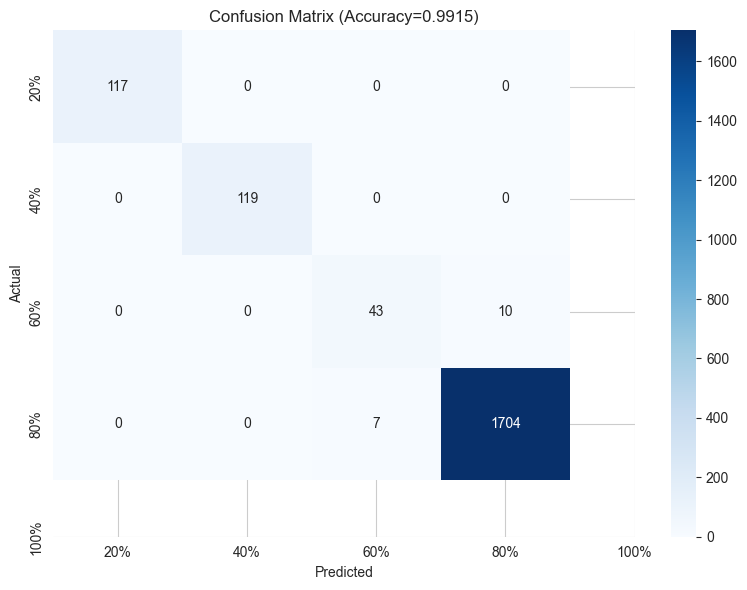

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'{inv_speed_map[i]}%' for i in range(5)],
            yticklabels=[f'{inv_speed_map[i]}%' for i in range(5)])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Accuracy={accuracy:.4f})')
plt.tight_layout(); plt.savefig(PLOT_DIR / "m2_confusion_matrix.png", dpi=120); plt.show()


## Step 8 â€” Save Model

In [8]:
model_path = MODEL_DIR / "m2_speed_optimizer.keras"
m.save(model_path)
print(f"Model saved to {model_path}")

# Verify load
from tensorflow.keras.models import load_model
loaded = load_model(model_path)
check = loaded.predict(X_test[:5], verbose=0)
check_classes = np.argmax(check, axis=1)
check_speeds = [inv_speed_map[c] for c in check_classes]
print(f"Verification (first 5): {check_speeds}")
print(f"Actual (first 5):       {[inv_speed_map[c] for c in y_test[:5]]}")


Model saved to E:\Projects\iot-aiml-project\ml_model\models\m2_speed_optimizer.keras


Verification (first 5): [100, 100, 100, 100, 100]
Actual (first 5):       [100, 100, 100, 100, 100]


## Step 9 â€” Summary

In [9]:
print("=" * 60)
print("M2 Speed Optimizer - Keras ANN Classifier Summary")
print("=" * 60)
print(f"Training rows:    {len(train_df)}")
print(f"Testing rows:     {len(test_df)}")
print(f"Features:         {len(FEATURES)}")
print(f"Architecture:     64->32->5 (softmax), Dropout 0.2/0.1")
print(f"")
print(f"Test accuracy:    {accuracy:.4f}")
print(f"Speed levels:     {list(inv_speed_map.values())}")
print(f"")
print(f"Target: Recommended_Speed")
print(f"Model: {model_path}")
print(f"Scaler: {MODEL_DIR / 'scaler_m2.pkl'}")


M2 Speed Optimizer - Keras ANN Classifier Summary
Training rows:    8000
Testing rows:     2000
Features:         17
Architecture:     64->32->5 (softmax), Dropout 0.2/0.1

Test accuracy:    0.9915
Speed levels:     [20, 40, 60, 80, 100]

Target: Recommended_Speed
Model: E:\Projects\iot-aiml-project\ml_model\models\m2_speed_optimizer.keras
Scaler: E:\Projects\iot-aiml-project\ml_model\models\scaler_m2.pkl
